In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import json
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from shapely.geometry import mapping
from rasterio.mask import mask
from rasterio.features import geometry_mask
from matplotlib import cm
import imageio.v2 as imageio
from rasterio.warp import transform_bounds

## Mapa microplásticos

In [2]:
gdf = gpd.read_file("../data/Predicciones/mapa_continuo.gpkg")
gdf = gdf.to_crs(epsg=4326)
gdf.head()


,lat,lon,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,microplastics_log_est,microplastics_est,profile_eco,geometry
0,-78.0,-175.5,543.707048,-1.775068,34.395912,1.680748,27.419722,1.907441,311.153168,59.152695,0.211114,0.235053,cold_open_sea,POINT (-175.5 -78)
1,-78.0,-175.0,533.294654,-1.775068,34.395912,1.243596,27.419722,1.907441,311.153168,59.152695,0.210195,0.233919,cold_open_sea,POINT (-175 -78)
2,-78.0,-173.0,543.143622,-1.808737,34.373737,-0.760849,27.574869,1.912899,312.213226,57.888039,0.308657,0.361595,cold_open_sea,POINT (-173 -78)
3,-78.0,-172.5,540.559218,-1.808737,34.373737,-0.805667,27.574869,1.912899,312.213226,57.888039,0.308657,0.361595,cold_open_sea,POINT (-172.5 -78)
4,-78.0,-172.0,535.905487,-1.808737,34.373737,-0.708566,27.574869,1.912899,312.213226,57.888039,0.308657,0.361595,cold_open_sea,POINT (-172 -78)


In [3]:
print(gdf.crs)
print(gdf.geometry.geom_type.unique())
print(len(gdf))

EPSG:4326
['Point']
127013


In [4]:
# Extraer lat/lon
lats = gdf["lat"].values
lons = gdf["lon"].values

# Valores únicos ordenados
lat_vals = np.unique(lats)
lon_vals = np.unique(lons)

print(len(lat_vals), len(lon_vals))
print("Lat range:", lat_vals.min(), lat_vals.max())
print("Lon range:", lon_vals.min(), lon_vals.max())

301 719
Lat range: -78.0 72.0
Lon range: -179.5 179.5


In [5]:
# Paso entre celdas
lat_step = np.unique(np.round(np.diff(lat_vals), 6))
lon_step = np.unique(np.round(np.diff(lon_vals), 6))

print("Lat step(s):", lat_step[:5])
print("Lon step(s):", lon_step[:5])


Lat step(s): [0.5]
Lon step(s): [0.5]


In [6]:
# Crear índices para lat y lon
lat_to_idx = {lat: i for i, lat in enumerate(lat_vals)}
lon_to_idx = {lon: j for j, lon in enumerate(lon_vals)}

# Inicializar matriz (lat, lon)
raster = np.full(
    (len(lat_vals), len(lon_vals)),
    np.nan,
    dtype=np.float32
)

# Rellenar con microplásticos
for lat, lon, val in zip(
    gdf["lat"].values,
    gdf["lon"].values,
    gdf["microplastics_log_est"].values
):
    i = lat_to_idx[lat]
    j = lon_to_idx[lon]
    raster[i, j] = val


In [7]:
print("Shape raster:", raster.shape)
print("NaNs:", np.isnan(raster).sum())
print("Min / Max:", np.nanmin(raster), np.nanmax(raster))


Shape raster: (301, 719)
NaNs: 89406
Min / Max: 0.004230463 10.127361


In [8]:
import rasterio
from rasterio.transform import from_origin


In [9]:
lat_res = lat_step[0]
lon_res = lon_step[0]

# esquina superior izquierda
west = lon_vals.min()
north = lat_vals.max()

transform = from_origin(
    west,
    north,
    lon_res,
    lat_res
)

In [10]:
raster_flipped = np.flipud(raster)

In [11]:
output_path = "../data/Predicciones/microplastics_log_est.tif"

with rasterio.open(
    output_path,
    "w",
    driver="GTiff",
    height=raster_flipped.shape[0],
    width=raster_flipped.shape[1],
    count=1,
    dtype="float32",
    crs="EPSG:4326",
    transform=transform,
    compress="lzw",
    nodata=np.nan
) as dst:
    dst.write(raster_flipped, 1)


In [12]:
with rasterio.open("../data/Predicciones/microplastics_log_est.tif") as src:
    print(src.crs)
    print(src.bounds)
    print(src.width, src.height)

EPSG:4326
BoundingBox(left=-179.5, bottom=-78.5, right=180.0, top=72.0)
719 301


In [ ]:
tif_path = "../data/Predicciones/microplastics_log_est.tif"
png_path = "../data/Predicciones/microplastics_log_est.png"

with rasterio.open(tif_path) as src:
    data = src.read(1)
    bounds = src.bounds

# máscara de NaNs
masked = np.ma.masked_invalid(data)

plt.figure(figsize=(12, 6))
plt.imshow(
    masked,
    cmap="coolwarm",
    origin="upper"  # MUY IMPORTANTE
)
plt.axis("off")

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0
)
plt.close()

print("Bounds:", bounds)

Bounds: BoundingBox(left=-179.5, bottom=-78.5, right=180.0, top=72.0)


In [14]:
import json

raster_bounds = [
    [bounds.bottom, bounds.left],
    [bounds.top, bounds.right],
]

with open("../data/Predicciones/microplastics_bounds.json", "w") as f:
    json.dump(raster_bounds, f)

print(raster_bounds)

[[-78.5, -179.5], [72.0, 180.0]]


In [15]:
tif_path = "../data/Predicciones/microplastics_log_est.tif"
png_path = "../data/Predicciones/microplastics_log_est.png"

with rasterio.open(tif_path) as src:
    data = src.read(1)
    bounds = src.bounds

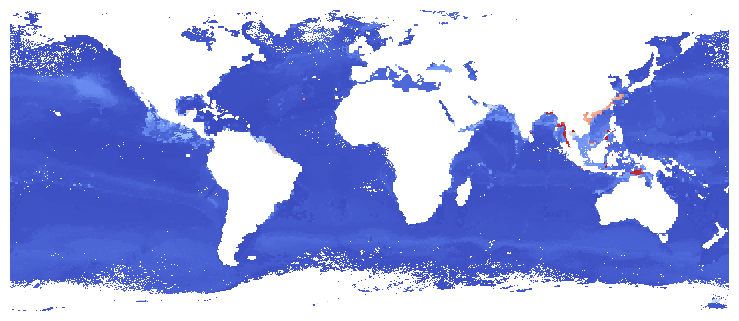

In [16]:
masked = np.ma.masked_invalid(data)

fig, ax = plt.subplots(
    figsize=(data.shape[1] / 100, data.shape[0] / 100),  # 👈 mantiene proporción
    dpi=100
)

ax.imshow(
    masked,
    cmap="coolwarm",
    origin="upper"
)

ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(
    png_path,
    dpi=100
)

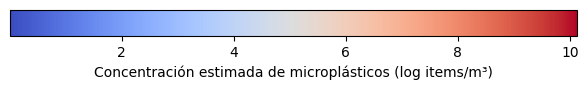

In [6]:

import matplotlib as mpl
# Rango (usa los mismos que en el mapa)
vmin = gdf["microplastics_log_est"].min()
vmax = gdf["microplastics_log_est"].max()
fig, ax = plt.subplots(figsize=(6, 1))

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.cm.coolwarm

cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=cmap,
    norm=norm,
    orientation="horizontal"
)

cb.set_label("Concentración estimada de microplásticos (log items/m³)")

plt.tight_layout()
plt.savefig("leyenda_microplasticos.png", dpi=300, bbox_inches="tight")
plt.show()

In [82]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

src_path = "../data/Predicciones/microplastics_log_est.tif"
dst_path = "../data/Predicciones/microplastics_log_est_3857.tif"

with rasterio.open(src_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, "EPSG:3857",
        src.width, src.height,
        *src.bounds
    )

    profile = src.profile.copy()
    profile.update({
        "crs": "EPSG:3857",
        "transform": transform,
        "width": width,
        "height": height,
        "compress": "lzw"
    })

    with rasterio.open(dst_path, "w", **profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs="EPSG:3857",
            resampling=Resampling.nearest
        )

In [18]:
with rasterio.open(dst_path) as src:
    data = src.read(1)
    bounds = src.bounds

masked = np.ma.masked_invalid(data)

fig, ax = plt.subplots(
    figsize=(data.shape[1] / 100, data.shape[0] / 100),
    dpi=100
)

ax.imshow(masked, cmap="coolwarm", origin="upper")
ax.axis("off")
plt.subplots_adjust(0, 0, 1, 1)

png_path = "../data/Predicciones/microplastics_log_est_3857.png"
plt.savefig(png_path)
plt.close()

In [19]:
import json

bounds_3857 = [
    [bounds.bottom, bounds.left],
    [bounds.top, bounds.right],
]

with open("../data/Predicciones/microplastics_bounds_3857.json", "w") as f:
    json.dump(bounds_3857, f)

print(bounds_3857)

[[-14632070.900886508, -19981848.597392607], [11753184.615338454, 19995811.275675517]]


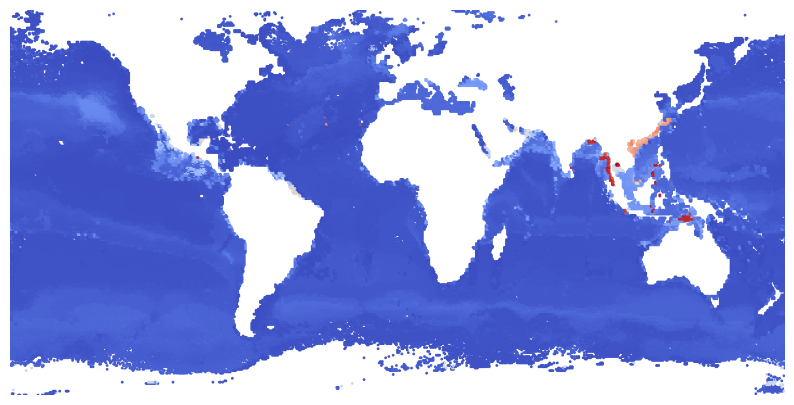

In [20]:

lon_min, lon_max = gdf.geometry.x.min(), gdf.geometry.x.max()
lat_min, lat_max = gdf.geometry.y.min(), gdf.geometry.y.max()

fig, ax = plt.subplots(figsize=(10, 5))

sc = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=gdf["microplastics_log_est"],
    cmap="coolwarm",
    s=1
)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

ax.set_aspect("auto")
ax.axis("off")


plt.savefig(
    "microplastics_map.png",
    dpi=300,
    pad_inches=0
)


plt.show()


In [21]:
# Límites espaciales para que coincida la imagen con mapa
bounds = [
    [float(lat_min), float(lon_min)],
    [float(lat_max), float(lon_max)],
]
with open("microplastics_bounds.json", "w") as f:
    json.dump(bounds, f)


In [22]:
[
  [lat_min, lon_min],
  [lat_max, lon_max]
]


[[np.float64(-78.0), np.float64(-179.5)],
 [np.float64(72.0), np.float64(179.5)]]

## Mapa mean risk

In [244]:
# Cargar y preparar datos
gdf1 = gpd.read_file("../data/Predicciones/species_count_prediction_with_confidence.gpkg")

# Solo océano y valores válidos
gdf1 = gdf1[gdf1["pred_iucn_mean_risk"].notna()].copy()

# Asegurar CRS geográfico
if gdf1.crs.to_epsg() != 4326:
    gdf1 = gdf1.to_crs(epsg=4326)

In [245]:
# Cargar tierra
land = gpd.read_file(
    "../data/ocean/ne_10m_land.shp"
).to_crs(epsg=4326)

# Asegurar geometría válida
gdf1["geometry_point"] = gdf1.geometry.centroid

# QUEDARSE SOLO CON OCÉANO
gdf1 = gdf1[
    ~gdf1["geometry_point"].apply(lambda p: land.contains(p).any())
].copy()

print("Celdas solo océano:", len(gdf1))

/tmp/ipykernel_2702/1901301147.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf1["geometry_point"] = gdf1.geometry.centroid


Celdas solo océano: 32214


In [246]:
# 1️⃣ Proyectar TODO a Web Mercator
gdf1 = gdf1.to_crs(epsg=3857)
land = land.to_crs(epsg=3857)

# Definir resolución del raster
RESOLUTION = 50_000  # grados (~50 km)

# Crear grid raster
minx, miny, maxx, maxy = gdf1.total_bounds

width = int((maxx - minx) / RESOLUTION)
height = int((maxy - miny) / RESOLUTION)

transform = from_bounds(minx, miny, maxx, maxy, width, height)

In [247]:
# Rasterizar riesgo ecológico medio
shapes = (
    (geom, value)
    for geom, value in zip(
        gdf1.geometry,
        gdf1["pred_iucn_mean_risk"]
    )
)

raster_risk = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=np.nan,
    dtype="float32"
)

In [249]:
# Bounds actuales en 3857
south_3857, west_3857, north_3857, east_3857 = miny, minx, maxy, maxx

# Convertir bounds a EPSG:4326
west, south, east, north = transform_bounds(
    "EPSG:3857",
    "EPSG:4326",
    west_3857, south_3857, east_3857, north_3857
)

In [251]:
# =====================================================
# GUARDAR BOUNDS PARA FOLIUM
# =====================================================

bounds_dict = {
    "south": south,
    "west": west,
    "north": north,
    "east": east,
}

import json
with open("pred_iucn_mean_risk_bounds.json", "w") as f:
    json.dump(bounds_dict, f)

In [ ]:
# west, south, east, north = minx, miny, maxx, maxy

In [252]:
# -----------------------------
# NORMALIZAR valores (robusto)
# -----------------------------
vmin = np.nanpercentile(raster_risk, 2)
vmax = np.nanpercentile(raster_risk, 98)

norm = np.clip((raster_risk - vmin) / (vmax - vmin), 0, 1)

# -----------------------------
# COLORMAP → RGBA
# -----------------------------
cmap = cm.get_cmap("YlOrRd")
rgba = cmap(norm)  # (H, W, 4) en float [0,1]

# Alpha = 0 donde NaN (tierra)
rgba[..., 3] = np.where(np.isnan(raster_risk), 0, 1)

# Convertir a uint8 (0–255)
rgba_uint8 = (rgba * 255).astype(np.uint8)

# -----------------------------
# GUARDAR PNG SIN ESCALADO
# -----------------------------
imageio.imwrite(
    "pred_iucn_mean_risk.png",
    rgba_uint8
)

/tmp/ipykernel_2702/1249452086.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


In [166]:
# Guardar GeoTIFF
with rasterio.open(
    "pred_iucn_mean_risk.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs="EPSG:4326",
    transform=transform,
    nodata=np.nan
) as dst:
    dst.write(raster_risk, 1)

In [167]:
from PIL import Image

img_png = Image.open("../data/Predicciones/pred_iucn_mean_risk.png")
print("PNG size:", img_png.size)
print("Raster shape:", raster_risk.shape[::-1])

PNG size: (719, 259)
Raster shape: (719, 259)


## Mapa species count

In [234]:
gdf2 = gpd.read_file("../data/Predicciones/species_count_prediction_with_confidence.gpkg")

# Solo océano y valores válidos
gdf2 = gdf2[gdf2["pred_log_iucn_species_count"].notna()].copy()

# Asegurar CRS geográfico
if gdf2.crs.to_epsg() != 4326:
    gdf2 = gdf2.to_crs(epsg=4326)

In [235]:
# Cargar tierra
land = gpd.read_file(
    "../data/ocean/ne_10m_land.shp"
).to_crs(epsg=4326)

# Asegurar geometría válida
gdf2["geometry_point"] = gdf2.geometry.centroid

# QUEDARSE SOLO CON OCÉANO
gdf2 = gdf2[
    ~gdf2["geometry_point"].apply(lambda p: land.contains(p).any())
].copy()

print("Celdas solo océano:", len(gdf2))

/tmp/ipykernel_2702/2892285338.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf2["geometry_point"] = gdf2.geometry.centroid


Celdas solo océano: 32214


In [236]:
minx, miny, maxx, maxy = gdf2.total_bounds

bounds_dict = {
    "south": miny,
    "west": minx,
    "north": maxy,
    "east": maxx,
}

with open("pred_log_iucn_species_count_bounds.json", "w") as f:
    json.dump(bounds_dict, f)

In [237]:
# =====================================================
# 2️⃣ Reproyectar a Web Mercator (solo para rasterizar)
# =====================================================

gdf2 = gdf2.to_crs(epsg=3857)

In [238]:
# Rasterización
RESOLUTION = 50_000  # grados (~50 km)

# Crear grid raster
minx, miny, maxx, maxy = gdf2.total_bounds

width = int((maxx - minx) / RESOLUTION)
height = int((maxy - miny) / RESOLUTION)

transform = from_bounds(minx, miny, maxx, maxy, width, height)

In [239]:
# Rasterizar especies vulnerables (escala log)
shapes_species = (
    (geom, value)
    for geom, value in zip(
        gdf2.geometry,
        gdf2["pred_log_iucn_species_count"]
    )
)

raster_species = rasterize(
    shapes=shapes_species,
    out_shape=(height, width),
    transform=transform,
    fill=np.nan,
    dtype="float32"
)

In [240]:
# =====================================================
# NORMALIZACIÓN ROBUSTA
# =====================================================

vmin = np.nanpercentile(raster_species, 2)
vmax = np.nanpercentile(raster_species, 98)

norm = np.clip(
    (raster_species - vmin) / (vmax - vmin),
    0,
    1
)

In [241]:
# =====================================================
# COLORMAP → RGBA
# =====================================================

cmap = cm.get_cmap("YlOrRd")
rgba = cmap(norm)  # (H, W, 4)

# Alpha = 0 donde NaN (tierra)
rgba[..., 3] = np.where(
    np.isnan(raster_species),
    0,
    1
)

rgba_uint8 = (rgba * 255).astype(np.uint8)

# =====================================================
# GUARDAR PNG (PARA STREAMLIT)
# =====================================================

imageio.imwrite(
    "pred_log_iucn_species_count.png",
    rgba_uint8
)

/tmp/ipykernel_2702/176505876.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


In [242]:
# =====================================================
# GUARDAR GEOTIFF (ARCHIVO MAESTRO)
# =====================================================

with rasterio.open(
    "pred_log_iucn_species_count.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs="EPSG:4326",
    transform=transform,
    nodata=np.nan
) as dst:
    dst.write(raster_species, 1)